In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from Preprocess import preprocess_data
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data(data)

In [3]:
# CatBoost
from catboost import CatBoostRegressor

# Avoiding any modification to original data sets since it uses column names and datatypes
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

cat_features = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()

#Tuning CatBoost in Optuna using the same method as XGBoost
def objective_cat(trial):
  CatBoost = CatBoostRegressor(
      iterations = 1000,
      learning_rate = trial.suggest_float("learning_rate",0.01,0.1,log=True),
      depth = trial.suggest_int("depth",2,8),
      loss_function = "MAE",
      eval_metric = "MAE",
      random_seed = 42,
      verbose=False,
      allow_writing_files=False,
      posterior_sampling=True,
      )

  CatBoost.fit(
      X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)
  predictions_cat = CatBoost.predict(X_val_cat)
  MAE_cat = mean_absolute_error(y_val, predictions_cat)
  return MAE_cat
optimization_cat= optuna.create_study(direction="minimize") #minimizing the above parameters
optimization_cat.optimize(objective_cat, n_trials=30) #keeping trails low for runtime and to prevent over-fitting noise

optimal_params_cat = optimization_cat.best_params
print("Optimal Parameters Cat:", optimal_params_cat)

#Running CatBoost with the optimal parameters
CatBoost = CatBoostRegressor(
    iterations = 1000,
    **optimal_params_cat,
    loss_function = "MAE",
    eval_metric = "MAE",
    random_seed = 42,
    verbose=False,
    allow_writing_files=False
    )

CatBoost.fit(
    X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)

# Calculating the multiplicative error
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_MAE = mean_absolute_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_MAE
print("CatBoost Error:", CatBoost_Error)

[I 2026-01-23 17:29:04,248] A new study created in memory with name: no-name-e00d7558-7b6c-4d98-b2bd-889fae946550
[I 2026-01-23 17:29:06,516] Trial 0 finished with value: 484.84411379649714 and parameters: {'learning_rate': 0.018669077868179403, 'depth': 7}. Best is trial 0 with value: 484.84411379649714.
[I 2026-01-23 17:29:07,227] Trial 1 finished with value: 499.2897119561875 and parameters: {'learning_rate': 0.016605247710744907, 'depth': 3}. Best is trial 0 with value: 484.84411379649714.
[I 2026-01-23 17:29:09,560] Trial 2 finished with value: 484.1705225875379 and parameters: {'learning_rate': 0.013596580893100329, 'depth': 7}. Best is trial 2 with value: 484.1705225875379.
[I 2026-01-23 17:29:12,767] Trial 3 finished with value: 486.0832557252556 and parameters: {'learning_rate': 0.04092671286630559, 'depth': 8}. Best is trial 2 with value: 484.1705225875379.
[I 2026-01-23 17:29:14,600] Trial 4 finished with value: 482.29993989527435 and parameters: {'learning_rate': 0.03408162

Optimal Parameters Cat: {'learning_rate': 0.05425070913664771, 'depth': 6}
CatBoost Error: 617.5090877325454


CatBoost Error: 617.5090877325454
Average Error per Record in seconds for Cat: 617.5090877325454
Sample0: True = 665.00s, Predicted = 818.06s, Error=153.06s
Sample1: True = 897.75s, Predicted = 830.78s, Error=66.97s
Sample2: True = 1377.25s, Predicted = 795.97s, Error=581.28s
Sample3: True = 1545.00s, Predicted = 872.62s, Error=672.38s
Sample4: True = 1230.00s, Predicted = 794.43s, Error=435.57s
Sample5: True = 803.75s, Predicted = 757.63s, Error=46.12s
Sample6: True = 790.00s, Predicted = 884.86s, Error=94.86s
Sample7: True = 1196.25s, Predicted = 1078.88s, Error=117.37s
Sample8: True = 920.00s, Predicted = 762.53s, Error=157.47s
Sample9: True = 715.00s, Predicted = 721.58s, Error=6.58s
Sample10: True = 1223.75s, Predicted = 870.23s, Error=353.52s
Sample11: True = 1396.25s, Predicted = 870.22s, Error=526.03s
Sample12: True = 1448.75s, Predicted = 1048.36s, Error=400.39s
Sample13: True = 1446.25s, Predicted = 1036.35s, Error=409.90s
Sample14: True = 1505.00s, Predicted = 1278.77s, Erro

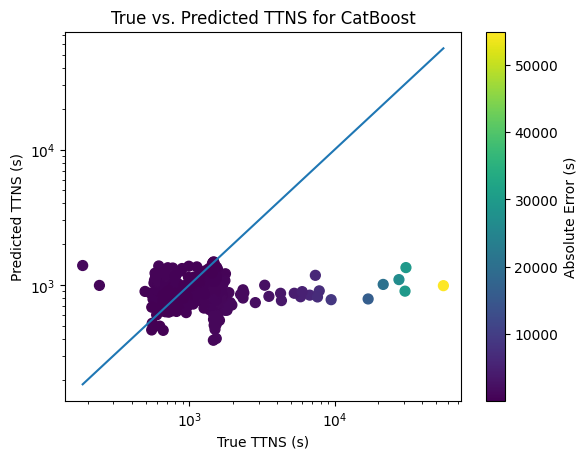

In [4]:
#Calculating multiplicative error for CatBoost
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_MAE = mean_absolute_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_MAE
print("CatBoost Error:", CatBoost_Error)

y_test_secs = y_test
Cat_pred_secs = CatBoost_Prediction

absolute_error_secs_Cat = np.abs(Cat_pred_secs - y_test_secs)

#absoulte_error_cat = np.abs(10**CatBoost_Prediction - y_test)
MAE_seconds = np.mean(absolute_error_secs_Cat)
print("Average Error per Record in seconds for Cat:", MAE_seconds)


#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, Cat_pred_secs, absolute_error_secs_Cat)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, Cat_pred_secs, c=absolute_error_secs_Cat, cmap='viridis', s=50)
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for CatBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()